<h2 style="color: #00fceb;">Import Pandas and pre-written modules.</h2>
<ul>
    <li style="color: #00fc7e; font-size: 20px">The pandas library is imported and assigned the alias "pd"</li>
    <li style="color: #00fc7e; font-size: 20px">This allows access to all pandas functionality via the pd namespace</li>
    <li style="color: #00fc7e; font-size: 20px">Pandas is required for reading, transforming, and saving structured data</li>
</ul>


<h2 style="color: #00fceb;">Growth Rate Analysis: Retail Deposit Portfolio</h2>

<p style="color: #00fc7e; font-size: 18px;">
Synthetic data analysis reproducing the handwritten notes for the retail deposit portfolio task. The notebook calculates growth rates of the total portfolio and its sum/FX components, derives portfolio shares for both reporting dates, and verifies that the structure is closed.
</p>

<p style="color: #00fc7e; font-size: 18px;">
Анализ синтетических данных, воспроизводящий рукописный конспект по задаче о розничном депозитном портфеле. Ноутбук рассчитывает темпы прироста совокупного портфеля и его сумовой/валютной частей, выводит доли в портфеле на обе отчётные даты и проверяет замкнутость структуры.
</p>

<h3 style="color: #00fceb;">Steps / Шаги</h3>
<ul>
    <li style="color: #00fc7e; font-size: 18px;">Load the synthetic dataset from <code>data/retail_deposit_portfolio.csv</code></li>
    <li style="color: #00fc7e; font-size: 18px;">Apply the <code>GrowthRate</code> class to the total portfolio, sum-denominated and FX components</li>
    <li style="color: #00fc7e; font-size: 18px;">Apply the <code>StructuralShift</code> class to compute portfolio shares and their changes in p.p.</li>
    <li style="color: #00fc7e; font-size: 18px;">Visualise the results: bar chart of growth rates and stacked bar of portfolio structure</li>
</ul>

In [16]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "3_python" / "formulas"))

from growth_rate import GrowthRate
from structural_shift import StructuralShift

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(Path.cwd().parent / "data" / "retail_deposit_portfolio.csv")
df["date"] = pd.to_datetime(df["date"])
df

,date,indicator,value,unit,currency
0,2024-01-01,total_portfolio,1250,UZS bn,UZS
1,2024-01-01,fx_component,320,UZS bn,UZS
2,2024-01-01,sum_component,930,UZS bn,UZS
3,2025-01-01,total_portfolio,1475,UZS bn,UZS
4,2025-01-01,fx_component,290,UZS bn,UZS
5,2025-01-01,sum_component,1185,UZS bn,UZS


<h2 style="color: #00fceb;">Data preview / Превью данных</h2>

<p style="color: #00fc7e; font-size: 18px;">
Quick inspection of the dataset before applying the calculations: shape, data types, basic descriptive statistics, and an integrity check that the sum of FX and sum-denominated components equals the total portfolio for each reporting date.
</p>

<p style="color: #00fc7e; font-size: 18px;">
Быстрый осмотр датасета перед применением расчётов: размер, типы данных, базовая описательная статистика и проверка целостности (сумма валютной и сумовой частей должна равняться совокупному портфелю на каждую отчётную дату).
</p>

In [17]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nDescriptive statistics:")
print(df["value"].describe())

print("\nIntegrity check (total = fx + sum):")
for current_date in df["date"].unique():
    rows = df[df["date"] == current_date]
    
    total = rows[rows["indicator"] == "total_portfolio"]["value"].iloc[0]
    fx = rows[rows["indicator"] == "fx_component"]["value"].iloc[0]
    sum_part = rows[rows["indicator"] == "sum_component"]["value"].iloc[0]
    
    check = fx + sum_part - total
    
    date_str = pd.Timestamp(current_date).strftime("%Y-%m-%d")
    print(f"{date_str}: total={total}, fx={fx}, sum={sum_part}, check={check}")

Shape: (6, 5)

Data types:
date         datetime64[us]
indicator               str
value                 int64
unit                    str
currency                str
dtype: object

Descriptive statistics:
count       6.000000
mean      908.333333
std       498.664884
min       290.000000
25%       472.500000
50%      1057.500000
75%      1233.750000
max      1475.000000
Name: value, dtype: float64

Integrity check (total = fx + sum):
2024-01-01: total=1250, fx=320, sum=930, check=0
2025-01-01: total=1475, fx=290, sum=1185, check=0


<h2 style="color: #00fceb;">Applying classes / Применение классов</h2>

<p style="color: #00fc7e; font-size: 18px;">
Extract values from the dataset and feed them into the GrowthRate and StructuralShift classes. The GrowthRate class is applied three times (total portfolio, sum-denominated component, FX component). The StructuralShift class is applied once for the whole portfolio decomposition.
</p>

<p style="color: #00fc7e; font-size: 18px;">
Извлечь значения из датасета и передать их в классы GrowthRate и StructuralShift. Класс GrowthRate применяется трижды (совокупный портфель, сумовая часть, валютная часть). Класс StructuralShift применяется один раз ко всей декомпозиции портфеля.
</p>

In [21]:
def get_value(date_str, indicator_name):
    rows = df[(df["date"] == date_str) & (df["indicator"] == indicator_name)]
    return rows["value"].iloc[0]

total_v0 = get_value("2024-01-01", "total_portfolio")
total_v1 = get_value("2025-01-01", "total_portfolio")

sum_v0 = get_value("2024-01-01", "sum_component")
sum_v1 = get_value("2025-01-01", "sum_component")

fx_v0 = get_value("2024-01-01", "fx_component")
fx_v1 = get_value("2025-01-01", "fx_component")

print(f"total: {total_v0} -> {total_v1}")
print(f"sum: {sum_v0} -> {sum_v1}")
print(f"fx: {fx_v0} -> {fx_v1}")

total: 1250 -> 1475
sum: 930 -> 1185
fx: 320 -> 290


In [24]:
total_gr = GrowthRate(v0=total_v0, v1=total_v1, name="Total Portfolio")
sum_gr= GrowthRate(v0=sum_v0,   v1=sum_v1,   name="Sum-denominated")
fx_gr = GrowthRate(v0=fx_v0,    v1=fx_v1,    name="FX Component")

growth_table = pd.DataFrame([
    {"indicator": total_gr.name, "v0": total_v0, "v1": total_v1, "growth_rate_%": total_gr.percentage()},
    {"indicator": sum_gr.name,   "v0": sum_v0,   "v1": sum_v1,   "growth_rate_%": sum_gr.percentage()},
    {"indicator": fx_gr.name,    "v0": fx_v0,    "v1": fx_v1,    "growth_rate_%": fx_gr.percentage()},
])

growth_table = growth_table.round({"growth_rate_%": 2})
growth_table

,indicator,v0,v1,growth_rate_%
0,Total Portfolio,1250,1475,18.00
1,Sum-denominated,930,1185,27.42
2,FX Component,320,290,-9.38


In [25]:
shift = StructuralShift(
    whole_v0=total_v0,
    whole_v1=total_v1,
    parts_v0={"FX": fx_v0, "Sum": sum_v0},
    parts_v1={"FX": fx_v1, "Sum": sum_v1},
    name="Retail Deposit Portfolio",
)

structure_table = pd.DataFrame(shift.summary_table())
structure_table = structure_table.round(2)
structure_table["closed"] = shift.check_closed()

structure_table

,part,share_v0,share_v1,delta_pp,closed
0,FX,25.6,19.66,-5.94,True
1,Sum,74.4,80.34,5.94,True


<h2 style="color: #00fceb;">Chart A: Growth rates by component / Темпы прироста по компонентам</h2>

<p style="color: #00fc7e; font-size: 18px;">
Bar chart showing the growth rate of each portfolio component between the two reporting dates. Green bars represent positive growth, red bars represent decline. The chart reproduces the numerical results from Steps 1-3 of the handwritten notes.
</p>

<p style="color: #00fc7e; font-size: 18px;">
Столбчатая диаграмма, показывающая темп прироста каждой компоненты портфеля между двумя отчётными датами. Зелёные столбцы - положительный рост, красные - сокращение. Диаграмма воспроизводит числовые результаты Шагов 1-3 из рукописного конспекта.
</p>

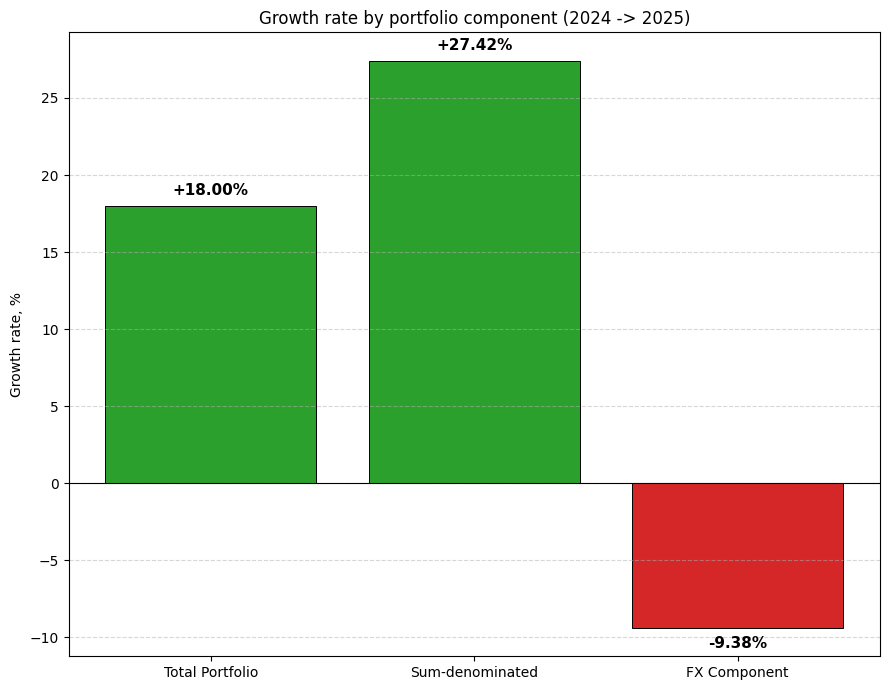

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))

names = growth_table["indicator"].tolist()
values = growth_table["growth_rate_%"].tolist()

colors = []
for v in values:
    if v >= 0:
        colors.append("#2ca02c")
    else:
        colors.append("#d62728")

bars = ax.bar(names, values, color=colors, edgecolor="black", linewidth=0.7)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Growth rate, %")
ax.set_title("Growth rate by portfolio component (2024 -> 2025)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

for i in range(len(bars)):
    bar = bars[i]
    v = values[i]
    height = bar.get_height()
    
    if height >= 0:
        y_position = height + 0.5
        v_align = "bottom"
    else:
        y_position = height - 0.5
        v_align = "top"
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{v:+.2f}%",
        ha="center",
        va=v_align,
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()